Regresie Liniară
==============


* Tudor Berariu, Andrei Nica 2018

* Alexandru Sorici 2020

## 1. Scopul Laboratorului

Scopul laboratorului îl reprezintă înțelegerea algoritmului de **regresie liniară**, precum și a noțiunilor de _extragere de atribute (features)_ _complexitate a modelului_ și _regularizare_.

## 2. Problema de rezolvat

Problema de rezolvat în acest laborator este una de învățare supervizată, mai concret, de **regresie**. 

Fiind date eșantionări de puncte (samples) **(X, t)**, generate de o funcție necunoscută, se dorește construirea unui **model liniar** care să poată _potrivi_ setul de date **X** (să aproximeze funcția) și care să poată fi utilizat pentru a _evalua/prezice_ valori noi.

Vom explora trei aspecte ale problemei de **regresie liniară**:
* Regresie liniara simplă (potrivirea unei drepte)
* Regresie liniară folosind **extragere de atribute** (eng. _feature extraction_)
* **Regularizare**, **analiza complexității modelului de regresie** și **influența numărului de date de antrenare**

## 3. Regresie liniară simplă

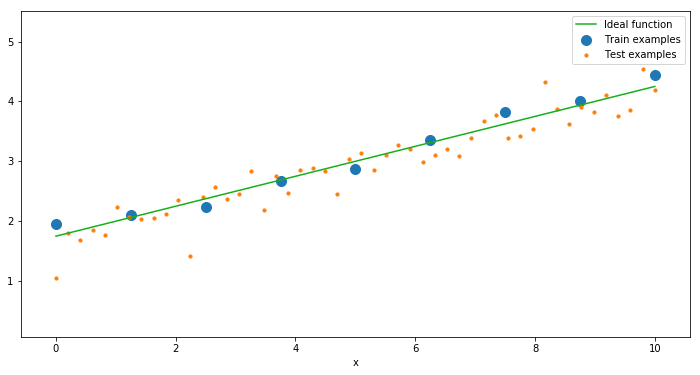

Se dă setul de date (**X**, **t**) constând dintr-o mulțime **X** de N puncte de dimensiune D (i.e. fiecare ${\bf x^{(i)}} \in {\bf X}$ este de forma ${\bf x} = (x_1, x_2, ..., x_D)$).
Pentru fiecare ${\bf x}^{(n)} \in X$ există un $t^{(n)}$ reprezentând valoarea unei funcții $f$ (necunoscute nouă) în punctul ${\bf x}^{(n)}$, i.e. $t^{(n)} = f({\bf x}^{(n)})$.

Un model de regresie liniară simplă care dorește să aproximeze funcția $f$ este definit ca $${\bf y} = {\bf X} {\bf w} + b$$ unde ${\bf w}$ este un vector D-dimensional de ponderi, iar $b$ este termenul de bias.

Pentru a obține o formă mai compactă a modelului de regresie liniară (care "absoarbe" termenul de bias în setul de ponderi ${\bf w}$), putem face o transformare simplă a unui exemplu ${\bf x}$. 

Anume: ${\bf \hat{x}} = (1, x_1, x_2, ..., x_D)$, astfel încât:

$$
y = {\bf \hat{x}} {\bf \hat{w}} = \begin{bmatrix} 1, x_1, x_2, ..., x_D \end{bmatrix} \begin{bmatrix} b \\\ w_1 \\\ w_2 \\\ . \\\ . \\\ . \\\ w_D \end{bmatrix}
$$


In regresia liniară simplă se caută soluția de **formă închisă**:
$${\bf w}^* = \underset{{\bf \hat{w}}}{\arg\!\min} \sum_{n} \left({\bf \hat{x}^{(n)}} {\bf \hat{w}} - t^{(n)}\right)^2$$
$${\bf w}^* = \left({\bf \hat{X}}^\intercal {\bf \hat{X}}\right)^{-1} {\bf \hat{X}}^\intercal {\bf t} = {\bf \hat{X}}^{\dagger} {\bf t}$$

unde ${\bf \hat{X}^{\dagger}}$ este _pseudo inversa_ matricii ${\bf \hat{X}}$.


## 4. Regresie liniară cu extragere de atribute

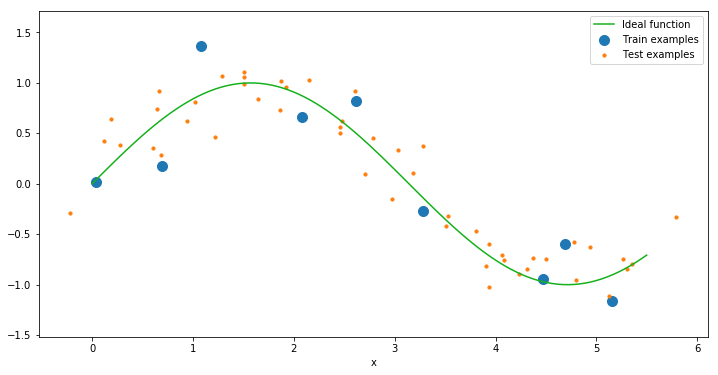

În unele cazuri, funcția $f$ din care provine setul de date (**X, t**) nu este una care sa poată fi aproximată printr-o simplă combinație liniară a **spațiului de intrare** (i.e. a domeniului din care provine **X**).

Într-un astfel de caz, spațiul de intrare poate fi _transformat_ într-unul mai complex, având o capabilitate de modelare mai bogată.

Acest lucru se face prin intermediul unor _funcții de transformare_ $\phi$ care duc ${\bf x^{(n)}} \rightarrow \phi({\bf x^{(n)}})$.

Un exemplu îl reprezintă funcțiile de **transformări polinomiale** de tipul:
$$\phi_i(x) = x^i, \quad 0 \le i \le M$$
unde $M$ este gradul polinomului cu care se face transformarea.

Soluția de regresie liniară (în formă inchisă) devine atunci:


$${\bf w}^* = \underset{{\bf w}}{\arg\!\min} \sum_{n} \left({\bf \phi}^{(n)}{\bf w} - t^{(n)}\right)^2$$


$${\bf w}^* = \left({\bf \Phi}^\intercal {\bf \Phi}\right)^{-1} {\bf \Phi}^\intercal {\bf t} = {\bf \Phi}^{\dagger} {\bf t}$$

## 5. Regresie liniară cu regularizare

O soluție de optimizare în sensul celor mai mici pătrate (_ordinary least squares - OLS_), caută să găsească _cea mai bună potrivire_ (best fit) pentru punctele din setul de date dat la antrenare.

Acest lucru duce la construirea unui estimator **unbiased**, i.e. modelul nu va prefera _prioritizarea_ unui feature (i.e. un anume $\phi^{(n)}$) în detrimentul altuia.
În plus, daca _modelul este complex,_  iar _datele de antrenare sunt puține,_ optimizarea OLS poate duce la fenomenul de **overfit** (i.e. modelul este prea specific pe datele de antrenare, dar nu are o evaluare bună pe date de test).

Un proces de **regularizare** are ca scop impunerea unei restricții asupra parametrilor ${\bf w}$, astfel încât modelul să poată da un bias acelor feature-uri care sunt mai relevante (importante) în construirea estimatorului.

Soluția de **regresie liniară cu regularizare L2** se scrie astfel:

$$\mathbf{w}^* = \operatorname*{arg\,min}_{\mathbf{w}} \sum_{n} \left(\boldsymbol{\phi}^{(n)}\mathbf{w} - t^{(n)}\right)^2 + \alpha \mathbf{w}^T\mathbf{w} \equiv \operatorname*{arg\,min}_{\mathbf{w}: \mathbf{w}^T\mathbf{w} \leq t(\alpha)} \sum_{n} \left(\boldsymbol{\phi}^{(n)}\mathbf{w} - t^{(n)}\right)^2$$

Soluția în formă închisă pentru regresia liniară cu regularizare L2 (eng. _Ridge Regression_) este dată prin:
$${\bf w}^* = \left({\bf \Phi}^\intercal {\bf \Phi} + \alpha I \right)^{-1} {\bf \Phi}^\intercal {\bf t}$$


### Dependențe

In [1]:
# Decomentați următoarele linii dacă nu aveți deja instalate bibliotecile
!pip install numpy
!pip install matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## 6. Generare seturi de date

In [3]:
DATASET_TYPE = "linear" # linear, polinomial, sin

In [4]:
def generate_examples(dataset_type = "linear", N = 9, noise = 0.2, dist_noise = 0.2) -> tuple[np.ndarray, np.ndarray]:
    if dataset_type == "linear":
        X = np.linspace(0, 10, N)
        t = X * 0.25 + 1.75 + np.random.randn(N) * noise
        return X, t
    
    elif dataset_type == "polinomial":
        X = np.linspace(-1.5, 5.5, N)
        X += np.random.randn(N) * dist_noise
        t = .25*X * X - X + 1 + np.random.randn(N) * noise
        return X, t
    
    elif dataset_type == "sin":
        X = np.linspace(0, 1.75 * np.pi, N)
        X += np.random.randn(N) * dist_noise
        t = np.sin(X) + np.random.randn(N) * noise
        return X, t
    
    else:
        raise ValueError("Unknown dataset type: " + dataset_type)

## 6. Implementarea modelului de regresie liniară

### 6.1 Cerința 1: Implementarea modelului general de regresie liniară

In [ ]:
class LinearRegression(object):
    """
    Modelul de Regresie Liniară
    y = X @ w 
        - valoarea prezisă de model
    t ~ N(t|X @ w, var) 
        - valorile de antrenare (target) fac parte dintr-o distribuție normală în jurul mediei X@w, 
          la care se adaugă zgomot dat de varianța `var`
    """

    def fit(self, X: np.ndarray, t: np.ndarray):
        """
        Antrenarea modelului in sensul celor mai mici patrate (least squares fitting)
        Parameterii
        ----------
        X : (N, D) np.ndarray
            variabilele de intrare
        t : (N,) np.ndarray
            variabilele țintă (target / ground truth)
        """
        print(X.shape)
        N, D = X.shape
        
        # TODO<1.1> calculați vectorul de ponderi w
        # Hint: operatorul de înmuțire de matrici în numpy este @
        # Hint: pentru a calcula psudo-inversa unei matrici M folosiți np.linalg.pinv(M)
        ## self.w = np.zeros(D) # TODO
        self.w = np.linalg.pinv(X) @ t # pseudoinversa matricei X inmultita cu vectorul t pentru a obtine vectorul de ponderi w care minimizeaza eroarea patratica intre predictiile modelului (X @ w) si valorile reale (t)
        # De ce se foloseste @? Pentru ca @ este operatorul de inmultire de matrici in numpy, care permite sa calculam produsul matriceal intre pseudoinversa lui X si vectorul t pentru a obtine vectorul de ponderi w. Acest operator este mai concis si mai eficient decat folosirea functiei np.dot sau a altor metode de inmultire de matrici.
        
        self.var = np.mean(np.square(X @ self.w - t))

    def predict(self, X: np.ndarray, return_std: bool=False) -> np.ndarray:
        """
        Întoarce valori prezise de model pentru sample-uri X
        Parametrii
        ----------
        X : (N, D) np.ndarray
            sample-uri de valori D-dimensionale pentru care se dorește predicția valorii conform modelului
        return_std : bool, optional
            întoarce deviația standard a fiecărei valori prezise, daca e setat pe True
        
        Întoarce
        -------
        y : (N,) np.ndarray
            vector de valori prezise
        y_std : (N,) np.ndarray
            deviația standard a fiecărei valori prezise
        """
        N, D = X.shape
        
        # TODO<1.2> calculați valoarea prezisă de modelul vostru
        ###y = np.zeros(N) # TODO
        y = X @ self.w
        
        if return_std:
            # TODO<1.3> întoarceți un vector de aceeași dimensiune cu y, care 
            # are în fiecare poziție o valoare egală cu deviația standard a modelului antrenat
            # (i.e. sqrt(var))
            ### y_std = np.zeros_like(y)  # TODO
            y_std = np.full_like(y, np.sqrt(self.var))
            
            return y, y_std
        return y

### 6.2 Cerința 2: Implementarea funcției de transformare polinomială
$$\phi_i(x) = x^i, \quad 0 \le i \le M$$

In [7]:
def extract_polynomial_features(X: np.ndarray, M: int) -> np.ndarray:
    # TODO<2> întoarceți valorile phi_n astfel încât pentru fiecare 
    # intrare x linia phi_n este [1, x, x^2, ..., x^M]
    # Notă: phi trebuie sa fie la final un np.array de dimensiune (N, M+1), unde N este numărul de linii din X    
    ##phi = X
    x = X.reshape(-1, 1)  # (N, 1)
    powers = np.arange(M + 1)  # 0..M
    phi = np.power(x, powers)  # broadcasting -> (N, M+1)

    return phi

extract_polynomial_features(np.array([1, 2]), 2)
# Pentru intrarea
# [1 
#  2]
# ne așteptăm la ierșire să avem matricea
# [ 1 1 1
#   1 2 4 ]
# adică:
# array([[1., 1., 1.],
#        [1., 2., 4.]])

array([[1, 1, 1],
       [1, 2, 4]])

### 6.3 Cerința 3: Potrivirea unei drepte prin regresie liniară simplă

In [11]:
N_train = 10
N_test = 10
noise = 0.22

# X_train se genereaza ca np.array de dimensiune (N_train, 1) - de notat ca este de forma unei matrici
# t_train se genereaza ca np.array de dimensiune (N_train, ) - de notat ca este un vector, nu o matrice
# similar se genereaza si X_real si t_real, X_test si t_test

X_train, t_train = generate_examples(dataset_type="linear", N=N_train, noise=noise)
X_test, t_test = generate_examples(dataset_type="linear", N=N_test, noise=noise)
X_real, t_real = generate_examples(dataset_type="linear", N=N_test, noise=0.)


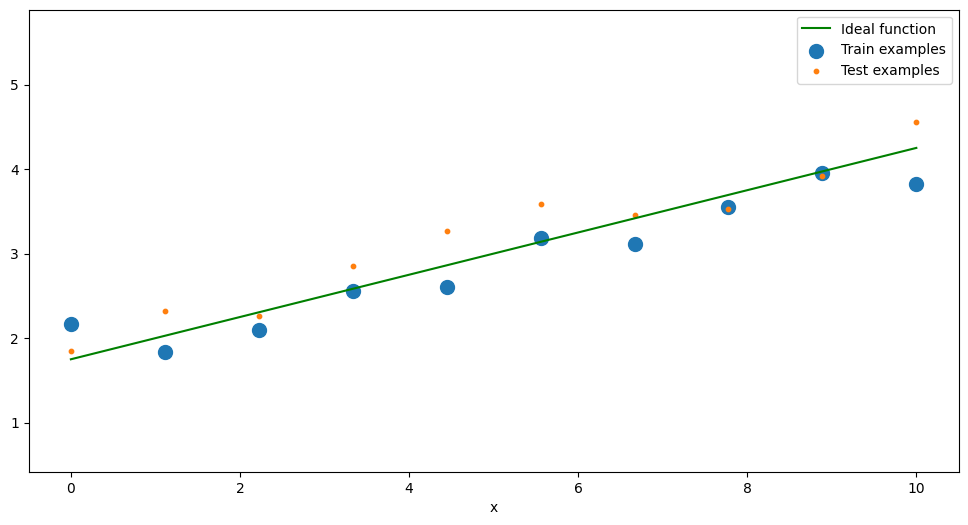

In [12]:
plt.figure(figsize=(12,6)); plt.axis('equal')
plt.plot(X_real, t_real, "green", label="Ideal function")
plt.scatter(X_train, t_train, s=100, label="Train examples")
plt.scatter(X_test, t_test, s=10, label="Test examples")
plt.xlabel("x")
plt.legend(bbox_to_anchor=(1, 1), loc='upper right', ncol=1)
plt.show()

In [13]:
y_train = np.zeros(X_train.size)
y_test = np.zeros(X_test.size)
y_test_std = np.zeros(X_test.size)

# TODO<3>:

# 1. Creați un model liniar instanțiind clasa LinearRegression
##model = None # TODO

# 2. Folosiți funcția extract_polynomial_features pentru a introduce termenul de bias în matricile X_train și X_test
##X_train_feat = None # TODO
##X_test_feat = None # TODO

# 3. Antrenați modelul vostru, folosind model.fit(...). Pentru antrenare, folosiți X_train_feat și targetul t_train

# 4. Obțineți predicția pe setul de antrenare (X_train_feat) și pe setul de test (X_test_feat), folosind model.predict(...) 
##y_train= None # TODO
##y_test, y_test_std = None # TODO

# 1. Creați un model liniar instanțiind clasa LinearRegression
model = LinearRegression()

# 2. Folosiți funcția extract_polynomial_features pentru a introduce termenul de bias
#    (M=1 -> coloane [1, x])
X_train_feat = extract_polynomial_features(X_train, M=1)
X_test_feat = extract_polynomial_features(X_test, M=1)

# 3. Antrenați modelul
model.fit(X_train_feat, t_train)

# 4. Predicții
y_train = model.predict(X_train_feat)
y_test, y_test_std = model.predict(X_test_feat, return_std=True)


(10, 2)


In [14]:
def mean_squared_error(y, t):
    return np.mean((y - t) * (y- t))

In [15]:
print("Train error:", mean_squared_error(y_train, t_train))
print("Test  error:", mean_squared_error(y_test, t_test))

Train error: 0.03595610812161991
Test  error: 0.11886753094808841


#### Vizualizarea modelului învățat

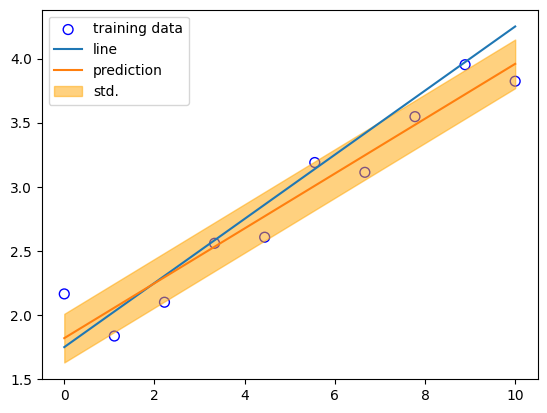

In [16]:
plt.scatter(X_train, t_train, facecolor="none", edgecolor="b", s=50, label="training data")
plt.plot(X_real, t_real, label="line")
plt.plot(X_test, y_test, label="prediction")
plt.fill_between(
    X_test, y_test - y_test_std, y_test + y_test_std,
    color="orange", alpha=0.5, label="std.")
plt.legend()
plt.show()

## 7. Cerința 4: Implementarea regresiei liniare cu regularizare (Ridge Regression)

In [17]:
class RidgeRegression(LinearRegression):
    """
    Modelul de regresie liniară, folosind regularizare L2
    w* = argmin |t - X @ w| + alpha * |w|_2^2
    """

    def __init__(self, alpha:float=1.):
        super(RidgeRegression, self).__init__()
        self.alpha = alpha
        

    def fit(self, X: np.ndarray, t: np.ndarray):
        """
        Antrenarea modelului în sensul celor mai mici patrate (least squares fitting), ținând cont și de regularizare.
        Parameterii
        ----------
         X : (N, D) np.ndarray
            variabilele de intrare
        t : (N,) np.ndarray
            variabilele țintă (target / ground truth)
        """
        N, D = X.shape
        # TODO<4> calculați vectorul de ponderi w, conform formulei de la punctul 5 
        # Hint: puteți inversa o matrice M cu np.linalg.solve(M)
        # Hint: matricea identitate este np.eye(dimensiune)
        ##self.w = np.zeros(D) # TODO
        ##self.var = None # TODO -- ca și la modelul fără regularizare

        A = X.T @ X + self.alpha * np.eye(D)
        b = X.T @ t
        self.w = np.linalg.solve(A, b)

        self.var = np.mean(np.square(X @ self.w - t))

## 7.1 Cerința 5: Potrivirea funcției sin(x) cu feature-uri polinomiale

**TODO<5> Analizați** modelele de regresie liniară _cu_ și _fără_ regularizare. Ce concluzii se deduc din graficele de vizualizare și din valorile funcției de eroare?

In [18]:
N_train = 20 #@param {type: "slider", default: 10, min: 10, max: 100}
N_test = 20
noise = 0.22

X_train, t_train = generate_examples(dataset_type="sin", N=N_train, noise=noise)
X_test, t_test = generate_examples(dataset_type="sin", N=N_test, noise=noise)
X_real, t_real = generate_examples(dataset_type="sin", N=100, noise=.0, dist_noise=.0)

### Folosirea unui model de regresie liniară, _fără_ regularizare

In [19]:
M = 8 #@param {type: "slider", default: 8, min: 1, max: 15}
X_train_feat = extract_polynomial_features(X_train, M)
X_test_feat = extract_polynomial_features(X_test, M)

model = LinearRegression()
model.fit(X_train_feat, t_train)

y_train = model.predict(X_train_feat, return_std=False) 
y_test, y_test_std = model.predict(X_test_feat, return_std=True)

(20, 9)


#### Vizualizarea modelului învățat

Train error: 0.03851643205012067
Test  error: 0.07181702963109061


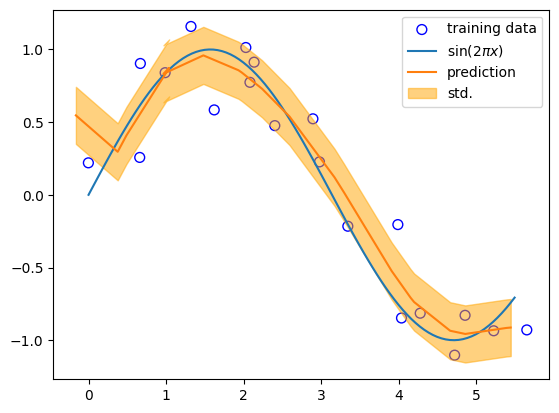

In [20]:
print("Train error:", mean_squared_error(y_train, t_train))
print("Test  error:", mean_squared_error(y_test, t_test))

# Plot
plt.scatter(X_train, t_train, facecolor="none", edgecolor="b", s=50, label="training data")
plt.plot(X_real, t_real, label="$\sin(2\pi x)$")
plt.plot(X_test, y_test, label="prediction")
plt.fill_between(
    X_test, y_test - y_test_std, y_test + y_test_std,
    color="orange", alpha=0.5, label="std.")
plt.legend()
plt.show()

### Folosirea unui model de regresie liniară, _cu_ regularizare

In [21]:
model = RidgeRegression(alpha=1.75)
model.fit(X_train_feat, t_train)

y_train = model.predict(X_train_feat, return_std=False) 
y_test, y_test_std = model.predict(X_test_feat, return_std=True)

Train error: 0.04460757905807476
Test  error: 0.04526474184366477


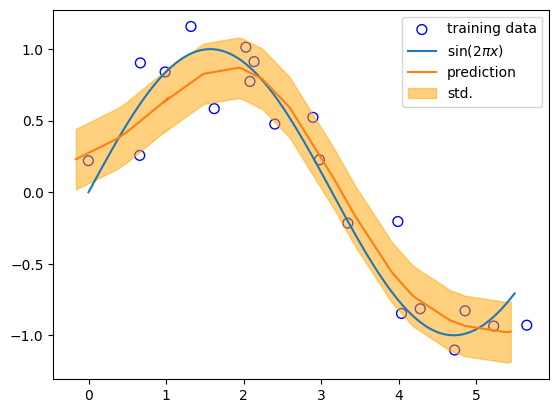

In [22]:
print("Train error:", mean_squared_error(y_train, t_train))
print("Test  error:", mean_squared_error(y_test, t_test))

# Plot
plt.scatter(X_train, t_train, facecolor="none", edgecolor="b", s=50, label="training data")
plt.plot(X_real, t_real, label="$\sin(2\pi x)$")
plt.plot(X_test, y_test, label="prediction")
plt.fill_between(
    X_test, y_test - y_test_std, y_test + y_test_std,
    color="orange", alpha=0.5, label="std.")
plt.legend()
plt.show()

## 8. Cerința 6: Vizualizarea curbelor de antrenare și testare

**TODO<6> Analizați** curbele de _antrenare_ și _testare_ pentru modele de regresie liniară _cu_ și _fără_ regularizare, de **complexitate** diferită (M diferit).

Discutați graficele rezultate:
 * care este regimul de underfitting?
 * care este regimul de overfitting?
 * ce se intamplă dacă variați numărul de date de antrenare (valoarea lui N_train de la punctul 7.1)?

(20, 1)
(20, 2)
(20, 3)
(20, 4)
(20, 5)
(20, 6)
(20, 7)
(20, 8)
(20, 9)
(20, 10)
(20, 11)
(20, 12)
(20, 13)
(20, 14)
(20, 15)


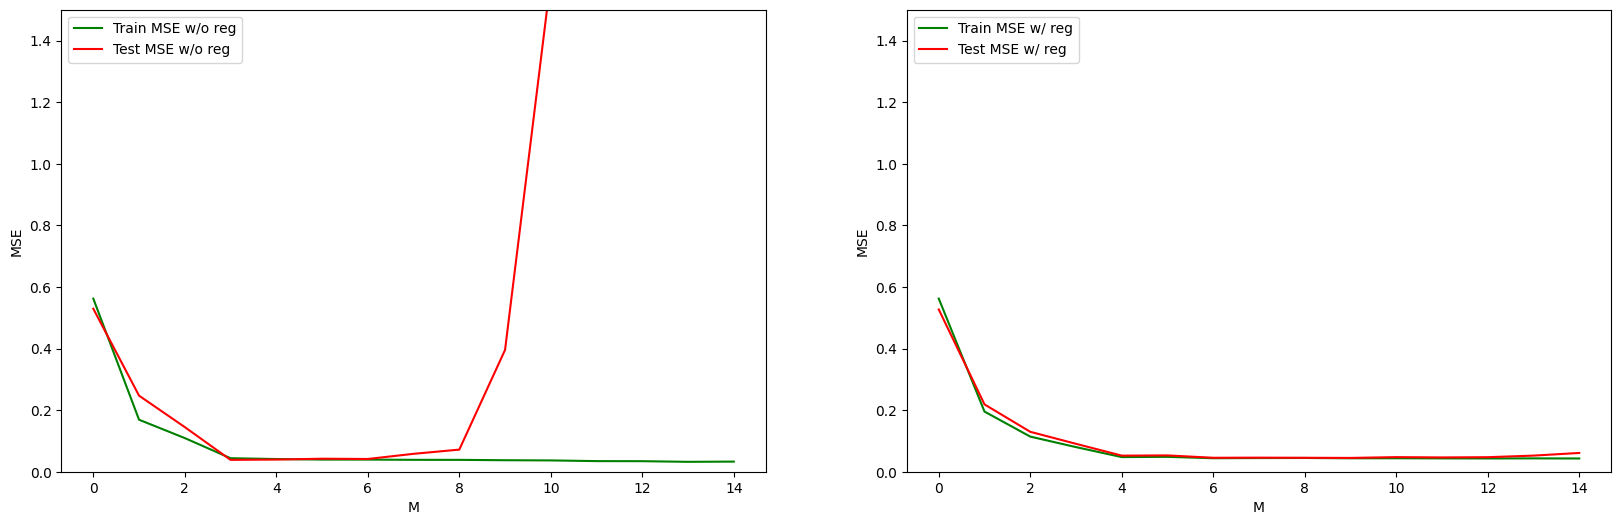

In [23]:
train_lin_mse = []
test_lin_mse = []

train_ridge_mse = []
test_ridge_mse = []

for M in range(15):
    X_train_feat = extract_polynomial_features(X_train, M)
    X_test_feat = extract_polynomial_features(X_test, M)
    
    model_linear = LinearRegression()
    model_ridge = RidgeRegression(alpha=1.75)
    
    model_linear.fit(X_train_feat, t_train)
    model_ridge.fit(X_train_feat, t_train)
    
    y_train_lin = model_linear.predict(X_train_feat)
    y_test_lin = model_linear.predict(X_test_feat)
    
    y_train_ridge = model_ridge.predict(X_train_feat)
    y_test_ridge = model_ridge.predict(X_test_feat)
    
    train_lin_mse.append(mean_squared_error(y_train_lin, t_train))
    test_lin_mse.append(mean_squared_error(y_test_lin, t_test))
    
    train_ridge_mse.append(mean_squared_error(y_train_ridge, t_train))
    test_ridge_mse.append(mean_squared_error(y_test_ridge, t_test))

plt.figure(figsize=(20,6))
# plot training/test curves depending on model size for LinearRegression
plt.subplot(1, 2, 1)
plt.plot(range(M+1), train_lin_mse, "green", label="Train MSE w/o reg")
plt.plot(range(M+1), test_lin_mse, "red", label="Test MSE w/o reg")
plt.xlabel("M")
plt.ylabel("MSE")
plt.legend(bbox_to_anchor=(0, 1), loc='upper left', ncol=1)
plt.ylim(0, 1.5)

# plot training/test curves depending on model size for RidgeRegression
plt.subplot(1, 2, 2)
plt.plot(range(M+1), train_ridge_mse, "green", label="Train MSE w/ reg")
plt.plot(range(M+1), test_ridge_mse, "red", label="Test MSE w/ reg")
plt.xlabel("M")
plt.ylabel("MSE")
plt.legend(bbox_to_anchor=(0, 1), loc='upper left', ncol=1)
plt.ylim(0, 1.5)

plt.show()

In [24]:
20

20